# Steam 标签、类型与市场定位分析

本 Notebook 延续前面 Notebook 04 和 Notebook 05 的分析，把重点放在 Steam 的 `tags`、`genres` 和 `categories` 上。

前面的 Notebook 已经说明：Steam 市场规模大、内容供给长尾明显，玩家反馈和热度指标也高度长尾。因此，本节不只做“Top 标签排行”，而是把标签理解为一种市场定位语言：它们描述游戏玩法、题材、体验和玩家预期，也能反映竞争强度与反馈表现。

本 Notebook 的核心问题是：Steam 标签和类型如何帮助我们理解游戏市场定位、竞争格局，以及未来相似游戏推荐系统可以利用哪些信息？

## 1. 读取数据与检查字段

本节读取 Notebook 03 生成的特征数据。因为大型 Parquet 文件不会上传到 GitHub，如果本地没有该文件，需要先运行 Notebook 03 重新生成。

本 Notebook 会继续使用 Notebook 05 中的玩家反馈和热度指标，例如评论数、好评率、推荐数和峰值在线人数。

In [1]:
from pathlib import Path
import ast
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATH = PROCESSED_DIR / "steam_march2025_features.parquet"
if not FEATURE_PATH.exists():
    raise FileNotFoundError(
        f"未找到 {FEATURE_PATH}。请先运行 notebooks/03_steam_data_cleaning_and_features.ipynb。"
    )

df = pd.read_parquet(FEATURE_PATH)
print(f"Loaded: {FEATURE_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_march2025_features.parquet
Shape: 89,618 rows x 63 columns


,appid,name,release_date,required_age,price,discount,dlc_count,windows,mac,linux,metacritic_score,achievements,recommendations,developers,publishers,categories,genres,user_score,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,supported_languages,full_audio_languages,short_description,about_the_game,release_date_parsed,release_year,game_age_years,genres_list,genres_count,categories_list,categories_count,tags_list,tags_count,developers_list,developers_count,publishers_list,publishers_count,supported_languages_list,supported_languages_count,full_audio_languages_list,full_audio_languages_count,is_free,platform_count,is_multi_platform,review_count_calc,positive_rate_calc,negative_rate_calc,short_description_length,about_the_game_length,has_peak_ccu,peak_ccu_log1p,recommendations_log1p
0,730,Counter-Strike 2,2012-08-21,0,0.000,0,1,True,False,True,0,1,4401572,['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",0,7480813,1135108,100000000 - 200000000,33189,879,5174,350,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86.000,8632939,82.000,96473,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",2012-08-21,2012,14.000,Action|Free To Play,2,Multi-player|Cross-Platform Multiplayer|Steam ...,11,FPS|Shooter|Multiplayer|Competitive|Action|Tea...,20,Valve,1,Valve,1,Czech|Danish|Dutch|English|Finnish|French|Germ...,29,English|Indonesian,2,True,2,True,8615921,86.825,13.175,224,879,True,14.008,15.297
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.000,0,0,True,False,False,0,37,1732007,['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",0,1487960,1024436,50000000 - 100000000,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59.000,2513842,68.000,16720,"['English', 'Korean', 'Simplified Chinese', 'F...",[],Play PUBG: BATTLEGROUNDS for free. Land on str...,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",2017-12-21,2017,9.000,Action|Adventure|Massively Multiplayer|Free To...,4,Multi-player|PvP|Online PvP|Stats|Remote Play ...,6,Survival|Shooter|Battle Royale|Multiplayer|FPS...,20,PUBG Corporation,1,"KRAFTON, Inc.",1,English|Korean|Simplified Chinese|French|Germa...,17,,0,True,1,False,2512396,59.225,40.775,293,478,True,13.332,14.365
2,570,Dota 2,2013-07-09,0,0.000,0,2,True,True,True,90,0,14337,['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",0,1998462,451338,200000000 - 500000000,43031,1536,898,892,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81.000,2452595,80.000,29366,"['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","Every day, millions of players worldwide enter...","The most-played game on Steam. Every day, mill...",2013-07-09,2013,13.000,Action|Strategy|Free To Play,3,Multi-player|Co-op|Steam Trading Cards|Steam W...,8,Free to Play|MOBA|Multiplayer|Strategy|e-sport...,20,Valve,1,Valve,1,Bulgarian|Czech|Danish|Dutch|English|Finnish|F...,28,English|Korean|Simplified Chinese|Vietnamese,4,True,3,True,2449800,81.577,18.423,319,1402,True,13.228,9.571
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.000,0,0,True,False,False,96,77,1803063,['Rockstar North'],['Rockstar Games'],"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",0,1719950,250012,50000000 - 100000000,19323,771,7101,74,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87.000,1803832,92.000,17517,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']",Grand Theft Auto V for PC offers players the o...,"When a young street hustler, 

In [2]:
required_columns = [
    "appid", "name", "genres", "categories", "tags",
    "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu",
    "price", "is_free", "platform_count", "release_year", "game_age_years"
]
column_check = pd.DataFrame({
    "column": required_columns,
    "exists": [col in df.columns for col in required_columns]
})
display(column_check)
missing = column_check.loc[~column_check["exists"], "column"].tolist()
if missing:
    print("Warning: 以下字段缺失，相关分析会跳过或降级：", missing)
else:
    print("All required columns are available.")

,column,exists
0,appid,True
1,name,True
2,genres,True
3,categories,True
4,tags,True
5,review_count_calc,True
6,positive_rate_calc,True
7,recommendations,True
8,peak_ccu,True
9,price,True


All required columns are available.


## 2. 多标签字段解析与分析指标准备

Steam 的标签字段有几种形式：有些字段看起来像 Python list，有些字段是 `|` 分隔的字符串，还有些 `tags` 字段在原始数据中是字典形式。为了统一分析，本节会把 `genres`、`categories` 和 `tags` 解析成列表，再展开成长表。

同时，本节继续构造几个解释性指标：

- `review_count_calc_log1p`：评论数量的 log 变换；
- `recommendations_log1p`：推荐数的 log 变换；
- `peak_ccu_log1p`：峰值在线人数的 log 变换；
- `attention_score_descriptive`：基于上述热度指标的描述性综合分数。

这个综合分数只用于排序和描述，不是预测模型。

In [3]:
def parse_multivalue(value):
    """将 list/dict/分隔字符串统一解析成标签列表。"""
    if value is None:
        return []
    if isinstance(value, float) and pd.isna(value):
        return []
    if isinstance(value, list):
        raw_items = value
    elif isinstance(value, dict):
        raw_items = list(value.keys())
    else:
        text = str(value).strip()
        if not text or text.lower() in {"nan", "none", "[]", "{}"}:
            return []
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, dict):
                raw_items = list(parsed.keys())
            elif isinstance(parsed, (list, tuple, set)):
                raw_items = list(parsed)
            else:
                raw_items = [parsed]
        except (ValueError, SyntaxError):
            raw_items = text.split(";") if ";" in text else text.split(",") if "," in text else [text]

    cleaned = []
    for item in raw_items:
        item_text = str(item).strip().strip("'\"")
        parts = item_text.split("|") if "|" in item_text else [item_text]
        for part in parts:
            part_text = str(part).strip().strip("'\"")
            if part_text and part_text.lower() not in {"nan", "none"}:
                cleaned.append(part_text)
    return list(dict.fromkeys(cleaned))


def explode_items(data, list_column, item_name):
    tmp = data[["appid", list_column]].copy().explode(list_column)
    tmp = tmp.rename(columns={list_column: item_name})
    tmp[item_name] = tmp[item_name].astype(str).str.strip()
    tmp = tmp[(tmp[item_name] != "") & (tmp[item_name].str.lower() != "nan")]
    return tmp


def save_figure(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")

analysis_df = df.copy()
for col in ["genres", "categories", "tags"]:
    analysis_df[f"{col}_items"] = analysis_df[col].apply(parse_multivalue) if col in analysis_df.columns else [[] for _ in range(len(analysis_df))]
    analysis_df[f"{col}_item_count"] = analysis_df[f"{col}_items"].apply(len)

for col in ["review_count_calc", "recommendations", "peak_ccu", "positive_rate_calc", "price", "platform_count", "release_year", "game_age_years"]:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

for col in ["review_count_calc", "recommendations", "peak_ccu"]:
    analysis_df[f"{col}_log1p"] = np.log1p(analysis_df[col].fillna(0).clip(lower=0))

analysis_df["has_reliable_positive_rate"] = analysis_df["review_count_calc"].fillna(0) >= 30
attention_components = ["review_count_calc_log1p", "recommendations_log1p", "peak_ccu_log1p"]
for col in attention_components:
    std = analysis_df[col].std()
    analysis_df[f"{col}_z"] = (analysis_df[col] - analysis_df[col].mean()) / std if std and not np.isnan(std) else 0
analysis_df["attention_score_descriptive"] = analysis_df[[f"{col}_z" for col in attention_components]].mean(axis=1)

genre_long = explode_items(analysis_df, "genres_items", "genre")
category_long = explode_items(analysis_df, "categories_items", "category")
tag_long = explode_items(analysis_df, "tags_items", "tag")

print(f"Genre assignments: {len(genre_long):,}")
print(f"Category assignments: {len(category_long):,}")
print(f"Tag assignments: {len(tag_long):,}")
display(analysis_df[["appid", "name", "genres_items", "categories_items", "tags_items"]].head())

Genre assignments: 258,236
Category assignments: 376,960
Tag assignments: 1,025,859


,appid,name,genres_items,categories_items,tags_items
0,730,Counter-Strike 2,"[Action, Free To Play]","[Multi-player, Cross-Platform Multiplayer, Ste...","[FPS, Shooter, Multiplayer, Competitive, Actio..."
1,578080,PUBG: BATTLEGROUNDS,"[Action, Adventure, Massively Multiplayer, Fre...","[Multi-player, PvP, Online PvP, Stats, Remote ...","[Survival, Shooter, Battle Royale, Multiplayer..."
2,570,Dota 2,"[Action, Strategy, Free To Play]","[Multi-player, Co-op, Steam Trading Cards, Ste...","[Free to Play, MOBA, Multiplayer, Strategy, e-..."
3,271590,Grand Theft Auto V Legacy,"[Action, Adventure]","[Single-player, Multi-player, PvP, Online PvP,...","[Open World, Action, Multiplayer, Crime, Autom..."
4,359550,Tom Clancy's Rainbow Six® Siege,[Action],"[Single-player, Multi-player, PvP, Online PvP,...","[FPS, PvP, e-sports, Multiplayer, Tactical, Sh..."


## 3. 标签、类型与分类的覆盖规模

首先观察 `genres`、`categories` 和 `tags` 的整体覆盖情况。这里的目标不是只找最大标签，而是理解 Steam 市场上哪些定位词最常见，以及标签体系的粒度差异。

In [4]:
def frequency_table(long_df, item_col, total_games, top_n=30):
    out = long_df[item_col].value_counts().reset_index()
    out.columns = [item_col, "game_count"]
    out["game_share"] = out["game_count"] / total_games
    return out.head(top_n)

total_games = analysis_df["appid"].nunique()
top_genres = frequency_table(genre_long, "genre", total_games, 25)
top_categories = frequency_table(category_long, "category", total_games, 25)
top_tags = frequency_table(tag_long, "tag", total_games, 40)

display(top_genres)
display(top_categories)
display(top_tags.head(25))

coverage_summary = pd.DataFrame({
    "field": ["genres", "categories", "tags"],
    "unique_items": [genre_long["genre"].nunique(), category_long["category"].nunique(), tag_long["tag"].nunique()],
    "total_assignments": [len(genre_long), len(category_long), len(tag_long)],
    "avg_items_per_game": [analysis_df["genres_item_count"].mean(), analysis_df["categories_item_count"].mean(), analysis_df["tags_item_count"].mean()],
    "median_items_per_game": [analysis_df["genres_item_count"].median(), analysis_df["categories_item_count"].median(), analysis_df["tags_item_count"].median()],
})
display(coverage_summary)

,genre,game_count,game_share
0,Indie,63189,0.705
1,Casual,38699,0.432
2,Action,36842,0.411
3,Adventure,35452,0.396
4,Simulation,18570,0.207
5,Strategy,17366,0.194
6,RPG,16342,0.182
7,Early Access,9113,0.102
8,Free To Play,8867,0.099
9,Sports,3939,0.044


,category,game_count,game_share
0,Single-player,84399,0.942
1,Family Sharing,75028,0.837
2,Steam Achievements,42841,0.478
3,Steam Cloud,22721,0.254
4,Full controller support,19535,0.218
5,Multi-player,16365,0.183
6,Partial Controller Support,11355,0.127
7,Steam Trading Cards,10431,0.116
8,PvP,10337,0.115
9,Co-op,8771,0.098


,tag,game_count,game_share
0,Indie,43408,0.484
1,Singleplayer,42723,0.477
2,Action,32315,0.361
3,Casual,31832,0.355
4,Adventure,30772,0.343
5,2D,22695,0.253
6,Simulation,15663,0.175
7,Strategy,15465,0.173
8,3D,14950,0.167
9,Puzzle,13923,0.155


,field,unique_items,total_assignments,avg_items_per_game,median_items_per_game
0,genres,33,258236,2.879,3.000
1,categories,40,376960,4.197,3.000
2,tags,452,1025859,11.259,12.000


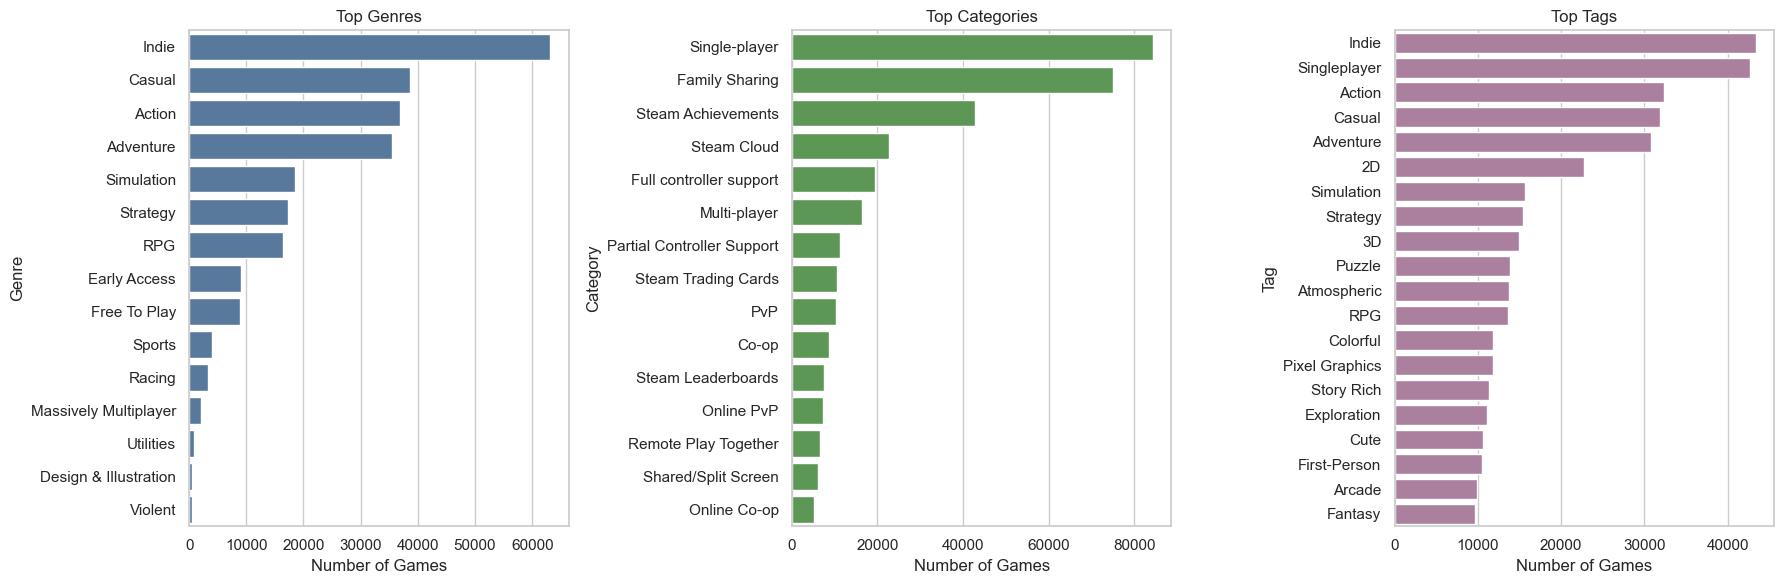

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/31_tag_genre_category_frequency.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=top_genres.head(15), y="genre", x="game_count", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top Genres")
axes[0].set_xlabel("Number of Games")
axes[0].set_ylabel("Genre")

sns.barplot(data=top_categories.head(15), y="category", x="game_count", ax=axes[1], color="#54A24B")
axes[1].set_title("Top Categories")
axes[1].set_xlabel("Number of Games")
axes[1].set_ylabel("Category")

sns.barplot(data=top_tags.head(20), y="tag", x="game_count", ax=axes[2], color="#B279A2")
axes[2].set_title("Top Tags")
axes[2].set_xlabel("Number of Games")
axes[2].set_ylabel("Tag")

save_figure("31_tag_genre_category_frequency.png")

从覆盖规模可以看出，`tags` 的表达粒度通常比 `genres` 更细，它不仅描述类型，也描述题材、视角、玩法和情绪体验。因此，标签比单纯类型更适合用于“市场定位”和未来相似游戏推荐。

## 4. 标签竞争度与反馈表现

本节把每个标签看作一个细分市场。一个标签出现的游戏越多，说明该定位方向供给越多，也可以粗略理解为竞争更强。

为了减少极小样本误导，本节只分析至少覆盖 50 款游戏的标签，并同时观察：

- `game_count`：供给规模 / 竞争度；
- `median_positive_rate_30plus`：较稳定评论样本中的好评率中位数；
- `median_review_count`：评论规模中位数；
- `mean_attention_score`：描述性综合热度分数。

In [6]:
tag_metrics = tag_long.merge(
    analysis_df[[
        "appid", "name", "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu",
        "attention_score_descriptive", "has_reliable_positive_rate", "price", "is_free", "platform_count", "release_year"
    ]],
    on="appid",
    how="left"
)

def median_positive_reliable_for_group(s):
    mask = tag_metrics.loc[s.index, "has_reliable_positive_rate"]
    return s[mask].median()

def count_reliable_for_group(s):
    return int(tag_metrics.loc[s.index, "has_reliable_positive_rate"].sum())

tag_summary = tag_metrics.groupby("tag").agg(
    game_count=("appid", "nunique"),
    reliable_review_game_count=("positive_rate_calc", count_reliable_for_group),
    median_review_count=("review_count_calc", "median"),
    mean_review_count=("review_count_calc", "mean"),
    median_positive_rate_30plus=("positive_rate_calc", median_positive_reliable_for_group),
    median_recommendations=("recommendations", "median"),
    median_peak_ccu=("peak_ccu", "median"),
    mean_attention_score=("attention_score_descriptive", "mean"),
    free_share=("is_free", "mean"),
    median_price=("price", "median"),
    median_release_year=("release_year", "median")
).reset_index()

tag_summary["game_share"] = tag_summary["game_count"] / total_games
tag_summary["competition_level"] = pd.qcut(
    tag_summary["game_count"].rank(method="first"),
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)
tag_summary_filtered = tag_summary[(tag_summary["game_count"] >= 50) & (tag_summary["reliable_review_game_count"] >= 20)].copy()

display(tag_summary_filtered.sort_values("game_count", ascending=False).head(20))
display(tag_summary_filtered.sort_values("median_positive_rate_30plus", ascending=False).head(20))

tag_summary.to_csv(PROCESSED_DIR / "steam_tag_positioning_summary.csv", index=False)
print("Saved:", PROCESSED_DIR / "steam_tag_positioning_summary.csv")

,tag,game_count,reliable_review_game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,mean_attention_score,free_share,median_price,median_release_year,game_share,competition_level
199,Indie,43408,20098,25.000,"1,106.581",80.658,0.000,0.000,0.076,0.097,4.990,"2,020.000",0.484,Very High
350,Singleplayer,42723,19573,23.000,"2,144.496",83.544,0.000,0.000,0.230,0.060,4.990,"2,022.000",0.477,Very High
17,Action,32315,14808,24.000,"3,199.940",79.642,0.000,0.000,0.173,0.094,4.990,"2,020.000",0.361,Very High
69,Casual,31832,13034,19.000,805.102,82.439,0.000,0.000,0.020,0.086,3.990,"2,021.000",0.355,Very High
23,Adventure,30772,15230,29.000,"2,190.479",81.395,0.000,0.000,0.218,0.077,4.990,"2,021.000",0.343,Very High
3,2D,22695,9694,20.000,989.555,86.553,0.000,0.000,0.099,0.061,4.990,"2,022.000",0.253,Very High
349,Simulation,15663,8371,36.000,"2,450.727",78.088,0.000,0.000,0.330,0.081,5.990,"2,021.000",0.175,Very High
377,Strategy,15465,7711,29.000,"2,768.615",78.788,0.000,0.000,0.282,0.092,4.990,"2,020.000",0.173,Very High
7,3D,14950,5382,15.000,992.943,81.538,0.000,0.000,0.031,0.061,4.990,"2,023.000",0.167,Very High
305,Puzzle,13923,6272,23.000,779.042,85.639,0.000,0.000,0.094,0.054,4.990,"2,021.000",0.155,Very High


,tag,game_count,reliable_review_game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,mean_attention_score,free_share,median_price,median_release_year,game_share,competition_level
362,Sokoban,555,180,16.000,135.467,93.952,0.000,0.000,-0.151,0.040,3.990,"2,022.000",0.006,Medium
97,Cozy,548,330,48.000,744.880,93.209,0.000,1.000,0.488,0.018,4.990,"2,024.000",0.006,Medium
445,Wholesome,419,255,55.000,727.136,92.405,0.000,0.000,0.417,0.010,4.990,"2,023.000",0.005,Medium
70,Cats,1027,502,29.000,620.627,92.179,0.000,0.000,0.106,0.046,3.990,"2,022.000",0.011,High
135,Electronic Music,97,31,15.000,307.113,90.247,0.000,0.000,-0.021,0.072,5.990,"2,022.000",0.001,Low
147,Faith,354,183,31.000,643.387,89.844,0.000,0.000,0.174,0.056,4.990,"2,022.000",0.004,Medium
57,Boss Rush,63,24,22.000,974.857,89.807,0.000,0.000,0.143,0.032,6.990,"2,023.000",0.001,Low
137,Emotional,2423,1285,34.000,"1,184.132",89.583,0.000,0.000,0.248,0.058,5.990,"2,023.000",0.027,Very High
212,LGBTQ+,1330,886,79.000,"1,322.425",89.572,0.000,0.000,0.457,0.071,6.990,"2,021.000",0.015,High
85,Collectathon,1418,526,17.000,509.810,89.434,0.000,0.000,0.040,0.044,4.990,"2,023.000",0.016,High


Saved: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_tag_positioning_summary.csv


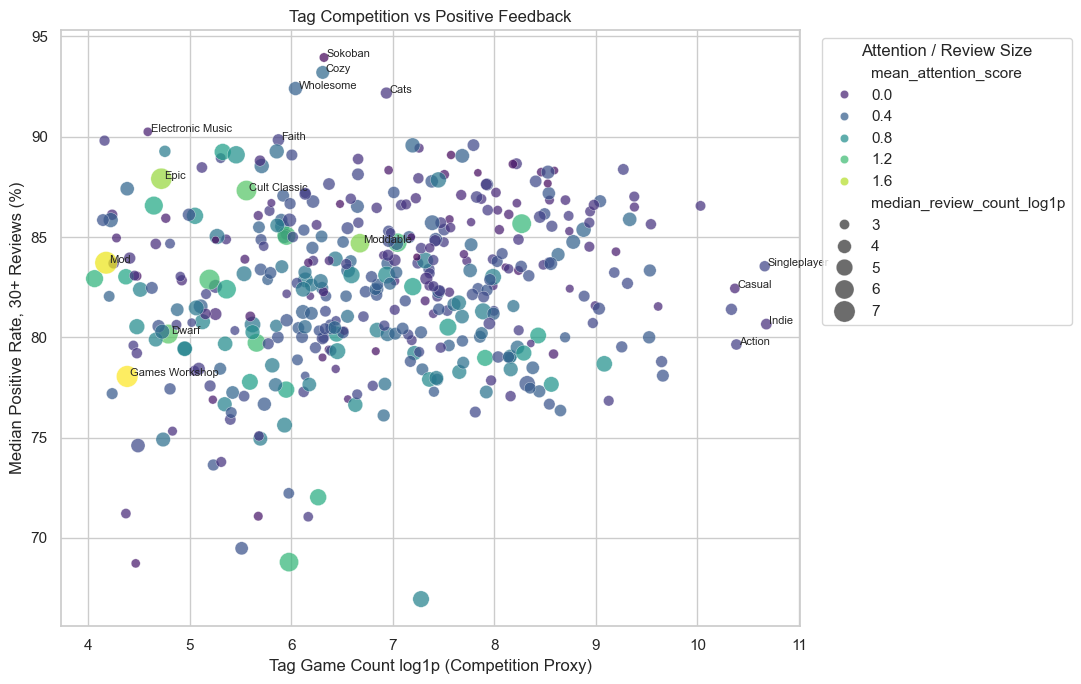

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/32_tag_competition_vs_positive_feedback.png


In [7]:
plot_tags = tag_summary_filtered.copy()
plot_tags["game_count_log1p"] = np.log1p(plot_tags["game_count"])
plot_tags["median_review_count_log1p"] = np.log1p(plot_tags["median_review_count"].fillna(0))

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=plot_tags,
    x="game_count_log1p",
    y="median_positive_rate_30plus",
    size="median_review_count_log1p",
    hue="mean_attention_score",
    palette="viridis",
    alpha=0.72,
    sizes=(30, 260),
    linewidth=0.3,
    edgecolor="white"
)
plt.title("Tag Competition vs Positive Feedback")
plt.xlabel("Tag Game Count log1p (Competition Proxy)")
plt.ylabel("Median Positive Rate, 30+ Reviews (%)")
plt.legend(title="Attention / Review Size", bbox_to_anchor=(1.02, 1), loc="upper left")

# 标注若干高反馈或高热度标签，避免散点图只是一团点。
label_candidates = pd.concat([
    plot_tags.sort_values("median_positive_rate_30plus", ascending=False).head(6),
    plot_tags.sort_values("mean_attention_score", ascending=False).head(6),
    plot_tags.sort_values("game_count", ascending=False).head(4)
]).drop_duplicates("tag")
for _, row in label_candidates.iterrows():
    ax.text(row["game_count_log1p"] + 0.03, row["median_positive_rate_30plus"], row["tag"], fontsize=8)

save_figure("32_tag_competition_vs_positive_feedback.png")

这个散点图把标签看作“定位市场”：横轴越靠右，说明该标签下游戏越多，竞争越强；纵轴越高，说明有足够评论样本的游戏反馈更正面；点的大小和颜色帮助观察热度表现。这个分析有助于从大量标签中筛选值得进一步研究的定位方向。

## 5. 低竞争高反馈标签与高热度标签

本节进一步整理几个课程报告中比较有用的标签表：

- 低竞争高反馈：游戏数量不太多，但好评率较高；
- 高热度标签：综合热度分数较高；
- 高竞争标签：出现频率很高，代表主流定位方向。

这些表可以为报告中的“市场机会”和“竞争格局”提供素材。

In [8]:
competition_q75 = tag_summary_filtered["game_count"].quantile(0.75)
competition_q50 = tag_summary_filtered["game_count"].quantile(0.50)
positive_q75 = tag_summary_filtered["median_positive_rate_30plus"].quantile(0.75)
attention_q75 = tag_summary_filtered["mean_attention_score"].quantile(0.75)

niche_high_feedback = tag_summary_filtered[
    (tag_summary_filtered["game_count"] <= competition_q50) &
    (tag_summary_filtered["median_positive_rate_30plus"] >= positive_q75) &
    (tag_summary_filtered["reliable_review_game_count"] >= 30)
].sort_values(["median_positive_rate_30plus", "mean_attention_score"], ascending=False)

high_attention_tags = tag_summary_filtered.sort_values("mean_attention_score", ascending=False).head(20)
high_competition_tags = tag_summary_filtered.sort_values("game_count", ascending=False).head(20)

print("低竞争高反馈标签候选：")
display(niche_high_feedback.head(20))
print("高热度标签：")
display(high_attention_tags[["tag", "game_count", "median_positive_rate_30plus", "median_review_count", "mean_attention_score"]].head(20))
print("高竞争标签：")
display(high_competition_tags[["tag", "game_count", "game_share", "median_positive_rate_30plus", "mean_attention_score"]].head(20))

niche_high_feedback.to_csv(PROCESSED_DIR / "steam_tag_niche_high_feedback_candidates.csv", index=False)
high_attention_tags.to_csv(PROCESSED_DIR / "steam_tag_high_attention_summary.csv", index=False)
print("Saved niche/high-attention tag summaries.")

低竞争高反馈标签候选：


,tag,game_count,reliable_review_game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,mean_attention_score,free_share,median_price,median_release_year,game_share,competition_level
362,Sokoban,555,180,16.000,135.467,93.952,0.000,0.000,-0.151,0.040,3.990,"2,022.000",0.006,Medium
97,Cozy,548,330,48.000,744.880,93.209,0.000,1.000,0.488,0.018,4.990,"2,024.000",0.006,Medium
445,Wholesome,419,255,55.000,727.136,92.405,0.000,0.000,0.417,0.010,4.990,"2,023.000",0.005,Medium
135,Electronic Music,97,31,15.000,307.113,90.247,0.000,0.000,-0.021,0.072,5.990,"2,022.000",0.001,Low
147,Faith,354,183,31.000,643.387,89.844,0.000,0.000,0.174,0.056,4.990,"2,022.000",0.004,Medium
211,LEGO,115,59,30.000,"2,789.861",89.274,0.000,0.000,0.641,0.061,5.990,"2,021.000",0.001,Low
263,Narrative,348,234,75.500,"1,362.463",89.271,0.000,0.000,0.510,0.055,9.990,"2,023.000",0.004,Medium
270,Nostalgia,204,134,155.500,"2,894.358",89.243,124.000,1.000,0.937,0.059,6.990,"2,021.000",0.002,Low
404,Touch-Friendly,233,178,241.000,"3,700.524",89.101,133.000,0.000,0.823,0.064,4.990,"2,017.000",0.003,Medium
301,Programming,404,198,27.500,660.267,89.091,0.000,0.000,0.251,0.069,7.990,"2,021.000",0.005,Medium


高热度标签：


,tag,game_count,median_positive_rate_30plus,median_review_count,mean_attention_score
170,Games Workshop,79,78.049,"1,313.000",1.824
246,Mod,64,83.717,"2,001.500",1.768
138,Epic,111,87.909,"1,002.000",1.514
247,Moddable,791,84.692,407.000,1.445
128,Dwarf,119,80.162,489.000,1.299
103,Cult Classic,258,87.319,668.500,1.295
210,Kickstarter,179,82.874,792.000,1.215
320,Remake,383,85.063,340.000,1.208
316,Real-Time with Pause,285,79.724,289.000,1.197
79,Classic,1145,84.722,381.000,1.194


高竞争标签：


,tag,game_count,game_share,median_positive_rate_30plus,mean_attention_score
199,Indie,43408,0.484,80.658,0.076
350,Singleplayer,42723,0.477,83.544,0.230
17,Action,32315,0.361,79.642,0.173
69,Casual,31832,0.355,82.439,0.020
23,Adventure,30772,0.343,81.395,0.218
3,2D,22695,0.253,86.553,0.099
349,Simulation,15663,0.175,78.088,0.330
377,Strategy,15465,0.173,78.788,0.282
7,3D,14950,0.167,81.538,0.031
305,Puzzle,13923,0.155,85.639,0.094


Saved niche/high-attention tag summaries.


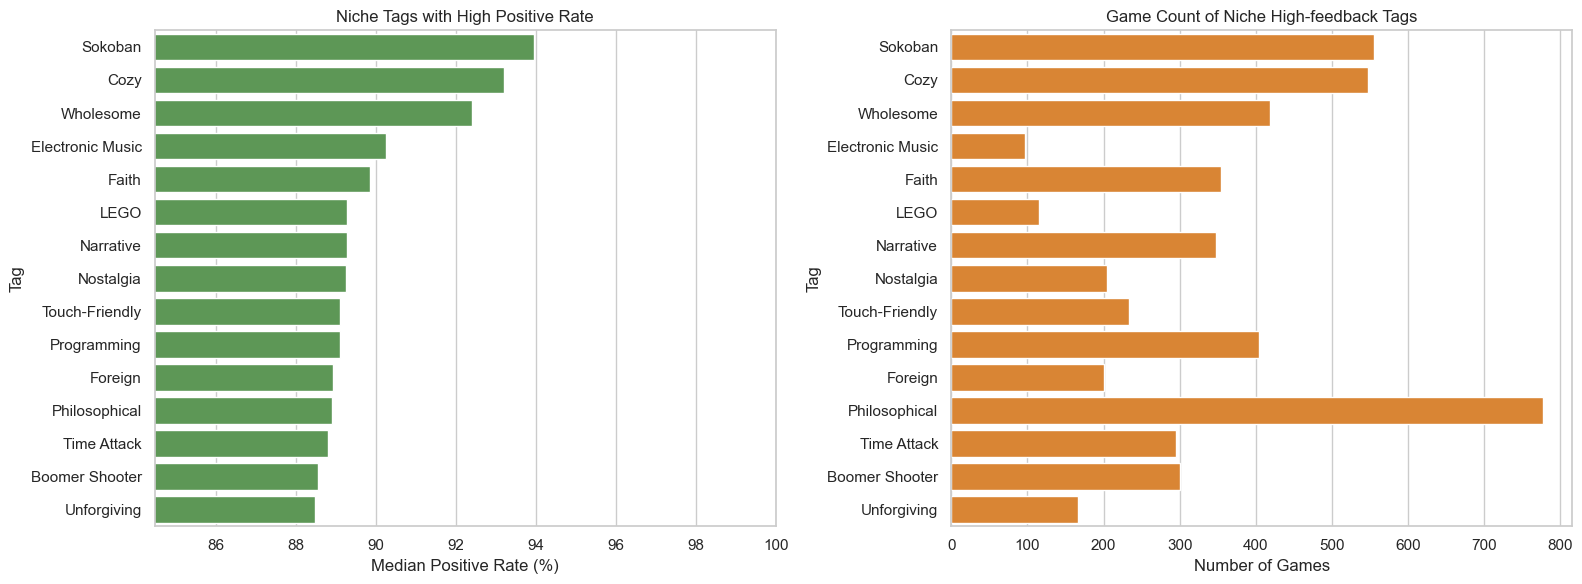

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/33_niche_high_feedback_tags.png


In [9]:
plot_niche = niche_high_feedback.head(15).copy()
if not plot_niche.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=plot_niche, y="tag", x="median_positive_rate_30plus", ax=axes[0], color="#54A24B")
    axes[0].set_title("Niche Tags with High Positive Rate")
    axes[0].set_xlabel("Median Positive Rate (%)")
    axes[0].set_ylabel("Tag")
    axes[0].set_xlim(max(0, plot_niche["median_positive_rate_30plus"].min() - 4), 100)

    sns.barplot(data=plot_niche, y="tag", x="game_count", ax=axes[1], color="#F58518")
    axes[1].set_title("Game Count of Niche High-feedback Tags")
    axes[1].set_xlabel("Number of Games")
    axes[1].set_ylabel("Tag")
    save_figure("33_niche_high_feedback_tags.png")
else:
    print("当前阈值下没有筛选出低竞争高反馈标签候选。")

“低竞争高反馈”不能直接理解为商业机会，因为标签背后还包含题材、开发成本、玩家圈层和发行策略等复杂因素。但它能帮助我们从大规模数据中找到值得进一步人工解读的细分方向。

## 6. 类型与标签的定位关系

`genres` 是较粗粒度类型，`tags` 是更细粒度的定位词。本节构造“类型-标签”矩阵，观察不同类型最常见的标签组合。

这里使用归一化比例：对于每个类型，统计该类型游戏中有多少比例带有某个标签。这样比单纯计数更适合比较不同规模的类型。

In [10]:
# 只选取头部类型和头部标签，避免矩阵过大难以阅读。
top_genre_list = top_genres.head(12)["genre"].tolist()
top_tag_list = top_tags.head(24)["tag"].tolist()

genre_game = genre_long[genre_long["genre"].isin(top_genre_list)][["appid", "genre"]].drop_duplicates()
tag_game = tag_long[tag_long["tag"].isin(top_tag_list)][["appid", "tag"]].drop_duplicates()

genre_tag_pairs = genre_game.merge(tag_game, on="appid", how="inner")
genre_counts = genre_game.groupby("genre")["appid"].nunique().rename("genre_game_count")
genre_tag_counts = genre_tag_pairs.groupby(["genre", "tag"])["appid"].nunique().reset_index(name="pair_count")
genre_tag_counts = genre_tag_counts.merge(genre_counts, on="genre", how="left")
genre_tag_counts["tag_share_within_genre"] = genre_tag_counts["pair_count"] / genre_tag_counts["genre_game_count"]

genre_tag_matrix = genre_tag_counts.pivot(index="genre", columns="tag", values="tag_share_within_genre").fillna(0)
genre_tag_matrix = genre_tag_matrix.loc[top_genre_list, [tag for tag in top_tag_list if tag in genre_tag_matrix.columns]]

display(genre_tag_matrix)
genre_tag_matrix.to_csv(PROCESSED_DIR / "steam_genre_tag_matrix_top.csv")
print("Saved:", PROCESSED_DIR / "steam_genre_tag_matrix_top.csv")

tag,Indie,Singleplayer,Action,Casual,Adventure,2D,Simulation,Strategy,3D,Puzzle,Atmospheric,RPG,Colorful,Pixel Graphics,Story Rich,Exploration,Cute,First-Person,Arcade,Fantasy,Early Access,Multiplayer,Funny,Horror
genre,,,,,,,,,,,,,,,,,,,,,,,,
Indie,0.653,0.480,0.389,0.386,0.365,0.278,0.172,0.173,0.172,0.175,0.168,0.158,0.143,0.152,0.127,0.136,0.128,0.122,0.122,0.108,0.114,0.087,0.103,0.106
Casual,0.489,0.454,0.260,0.727,0.286,0.271,0.186,0.173,0.150,0.206,0.135,0.099,0.177,0.105,0.095,0.095,0.170,0.080,0.134,0.089,0.079,0.075,0.114,0.051
Action,0.512,0.467,0.809,0.277,0.379,0.246,0.119,0.116,0.203,0.085,0.151,0.152,0.135,0.167,0.091,0.125,0.097,0.152,0.187,0.111,0.137,0.143,0.108,0.109
Adventure,0.488,0.492,0.392,0.318,0.767,0.258,0.135,0.118,0.180,0.189,0.226,0.216,0.137,0.148,0.217,0.223,0.131,0.154,0.070,0.144,0.095,0.066,0.103,0.153
Simulation,0.433,0.473,0.238,0.393,0.261,0.178,0.744,0.264,0.222,0.099,0.151,0.139,0.122,0.078,0.103,0.144,0.118,0.160,0.075,0.057,0.147,0.106,0.101,0.071
Strategy,0.463,0.485,0.242,0.375,0.236,0.283,0.277,0.790,0.163,0.163,0.110,0.206,0.129,0.124,0.082,0.088,0.104,0.062,0.058,0.141,0.138,0.128,0.079,0.045
RPG,0.442,0.463,0.329,0.236,0.463,0.284,0.154,0.213,0.132,0.070,0.119,0.753,0.092,0.183,0.209,0.167,0.111,0.073,0.035,0.254,0.138,0.074,0.077,0.065
Early Access,0.452,0.384,0.444,0.273,0.285,0.166,0.231,0.205,0.244,0.064,0.121,0.199,0.106,0.099,0.065,0.147,0.077,0.163,0.087,0.116,0.817,0.166,0.074,0.078
Free To Play,0.258,0.174,0.189,0.186,0.150,0.095,0.080,0.098,0.063,0.044,0.053,0.090,0.043,0.050,0.043,0.039,0.041,0.054,0.038,0.048,0.063,0.128,0.044,0.047


Saved: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_genre_tag_matrix_top.csv


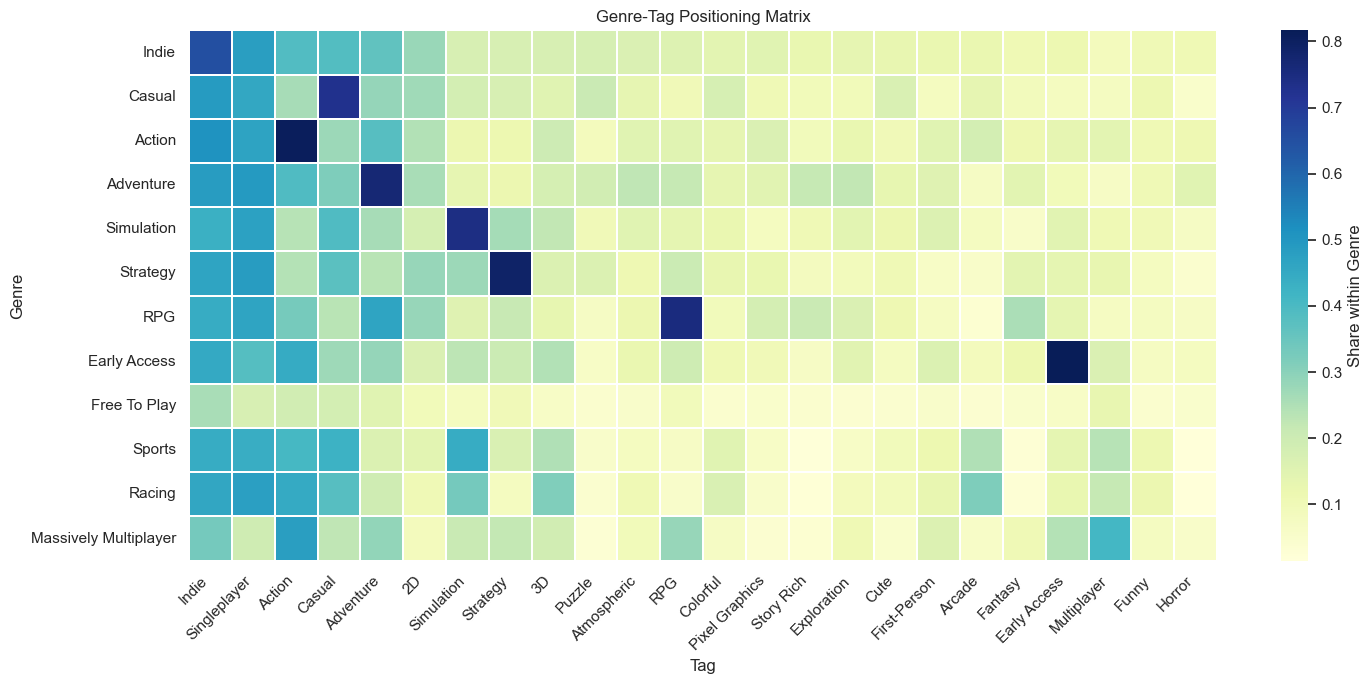

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/34_genre_tag_positioning_heatmap.png


In [11]:
plt.figure(figsize=(15, 7))
sns.heatmap(
    genre_tag_matrix,
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Share within Genre"}
)
plt.title("Genre-Tag Positioning Matrix")
plt.xlabel("Tag")
plt.ylabel("Genre")
plt.xticks(rotation=45, ha="right")
save_figure("34_genre_tag_positioning_heatmap.png")

类型-标签矩阵展示了“粗类型”和“细定位”的关系。例如同样是 `Action`，它可能与多人、射击、冒险等标签组合；而 `Casual` 可能更多连接到休闲、单人、解谜等定位词。这个矩阵也是未来做相似游戏推荐时的重要输入思路。

## 7. 标签共现结构

如果两个标签经常出现在同一款游戏中，说明它们可能共同描述一种稳定的游戏定位。例如某些玩法、视角和题材标签可能形成固定组合。

本节使用 Top 标签构造共现矩阵，并用 Jaccard 相似度进行归一化，避免仅仅因为大标签频率高就看起来和所有标签都相关。

In [12]:
cooccurrence_tags = top_tags.head(30)["tag"].tolist()
tag_sets = analysis_df[["appid", "tags_items"]].copy()
tag_sets["top_tag_set"] = tag_sets["tags_items"].apply(lambda items: sorted(set(items).intersection(cooccurrence_tags)))

tag_index = {tag: i for i, tag in enumerate(cooccurrence_tags)}
cooc_counts = np.zeros((len(cooccurrence_tags), len(cooccurrence_tags)), dtype=int)
tag_counts_for_matrix = np.zeros(len(cooccurrence_tags), dtype=int)

for items in tag_sets["top_tag_set"]:
    for tag in items:
        tag_counts_for_matrix[tag_index[tag]] += 1
    for a, b in combinations(items, 2):
        ia, ib = tag_index[a], tag_index[b]
        cooc_counts[ia, ib] += 1
        cooc_counts[ib, ia] += 1
np.fill_diagonal(cooc_counts, tag_counts_for_matrix)

jaccard = np.zeros_like(cooc_counts, dtype=float)
for i in range(len(cooccurrence_tags)):
    for j in range(len(cooccurrence_tags)):
        union = tag_counts_for_matrix[i] + tag_counts_for_matrix[j] - cooc_counts[i, j]
        jaccard[i, j] = cooc_counts[i, j] / union if union else 0

cooc_matrix = pd.DataFrame(cooc_counts, index=cooccurrence_tags, columns=cooccurrence_tags)
jaccard_matrix = pd.DataFrame(jaccard, index=cooccurrence_tags, columns=cooccurrence_tags)

display(jaccard_matrix.iloc[:10, :10])
cooc_matrix.to_csv(PROCESSED_DIR / "steam_tag_cooccurrence_counts_top.csv")
jaccard_matrix.to_csv(PROCESSED_DIR / "steam_tag_cooccurrence_jaccard_top.csv")
print("Saved tag co-occurrence matrices.")

,Indie,Singleplayer,Action,Casual,Adventure,2D,Simulation,Strategy,3D,Puzzle
Indie,1.000,0.449,0.360,0.386,0.346,0.262,0.176,0.178,0.138,0.187
Singleplayer,0.449,1.000,0.327,0.354,0.358,0.366,0.197,0.190,0.236,0.221
Action,0.360,0.327,1.000,0.204,0.301,0.207,0.108,0.106,0.191,0.079
Casual,0.386,0.354,0.204,1.000,0.234,0.266,0.193,0.176,0.149,0.230
Adventure,0.346,0.358,0.301,0.234,1.000,0.214,0.123,0.106,0.160,0.186
2D,0.262,0.366,0.207,0.266,0.214,1.000,0.099,0.161,0.015,0.198
Simulation,0.176,0.197,0.108,0.193,0.123,0.099,1.000,0.198,0.158,0.070
Strategy,0.178,0.190,0.106,0.176,0.106,0.161,0.198,1.000,0.106,0.121
3D,0.138,0.236,0.191,0.149,0.160,0.015,0.158,0.106,1.000,0.118
Puzzle,0.187,0.221,0.079,0.230,0.186,0.198,0.070,0.121,0.118,1.000


Saved tag co-occurrence matrices.


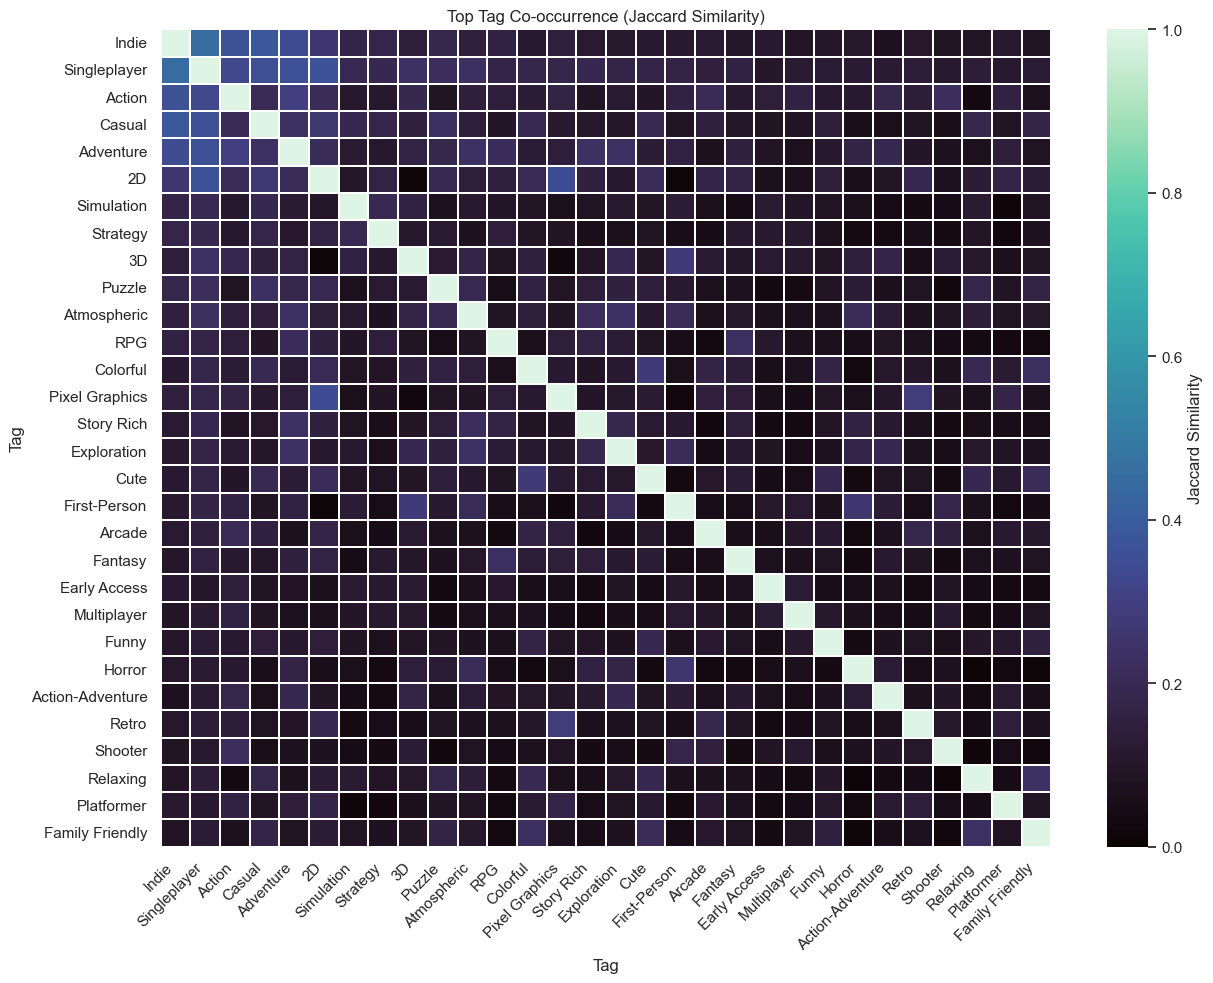

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/35_tag_cooccurrence_jaccard_heatmap.png


In [13]:
plt.figure(figsize=(13, 10))
sns.heatmap(
    jaccard_matrix,
    cmap="mako",
    vmin=0,
    vmax=np.nanpercentile(jaccard_matrix.values, 98),
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Jaccard Similarity"}
)
plt.title("Top Tag Co-occurrence (Jaccard Similarity)")
plt.xlabel("Tag")
plt.ylabel("Tag")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
save_figure("35_tag_cooccurrence_jaccard_heatmap.png")

In [14]:
cooc_pairs = []
for i, tag_a in enumerate(cooccurrence_tags):
    for j, tag_b in enumerate(cooccurrence_tags):
        if i < j:
            cooc_pairs.append({
                "tag_a": tag_a,
                "tag_b": tag_b,
                "cooccurrence_count": int(cooc_counts[i, j]),
                "jaccard_similarity": float(jaccard[i, j])
            })
cooc_pair_df = pd.DataFrame(cooc_pairs).sort_values("jaccard_similarity", ascending=False)
display(cooc_pair_df.head(25))
cooc_pair_df.to_csv(PROCESSED_DIR / "steam_tag_cooccurrence_pairs_top.csv", index=False)
print("Saved:", PROCESSED_DIR / "steam_tag_cooccurrence_pairs_top.csv")

,tag_a,tag_b,cooccurrence_count,jaccard_similarity
0,Indie,Singleplayer,26699,0.449
2,Indie,Casual,20948,0.386
32,Singleplayer,2D,17542,0.366
1,Indie,Action,20027,0.360
31,Singleplayer,Adventure,19386,0.358
30,Singleplayer,Casual,19501,0.354
142,2D,Pixel Graphics,8942,0.350
3,Indie,Adventure,19057,0.346
29,Singleplayer,Action,18486,0.327
58,Action,Adventure,14581,0.301


Saved: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_tag_cooccurrence_pairs_top.csv


标签共现可以揭示 Steam 市场中的“组合定位”。这些组合比单个标签更接近玩家实际理解游戏的方式，也更接近未来推荐系统中可以使用的相似度信号。

## 8. 独立游戏定位：Indie 标签的相对特征

前面的市场结构分析显示 `Indie` 是最常见的类型/标签之一。这里进一步把包含 `Indie` 类型或标签的游戏作为一个子市场，分析哪些标签在独立游戏中更突出。

这里使用 lift 指标：

> lift = Indie 游戏中某标签占比 / 非 Indie 游戏中某标签占比

lift 越高，说明该标签更偏向独立游戏定位。

In [15]:
analysis_df["is_indie_positioned"] = analysis_df.apply(
    lambda row: ("Indie" in set(row["genres_items"])) or ("Indie" in set(row["tags_items"])),
    axis=1
)

indie_games = analysis_df[analysis_df["is_indie_positioned"]]
non_indie_games = analysis_df[~analysis_df["is_indie_positioned"]]
print(f"Indie-positioned games: {len(indie_games):,} ({len(indie_games) / len(analysis_df):.2%})")
print(f"Non-Indie-positioned games: {len(non_indie_games):,}")

indie_tag_long = explode_items(indie_games, "tags_items", "tag")
non_indie_tag_long = explode_items(non_indie_games, "tags_items", "tag")

indie_tag_counts = indie_tag_long["tag"].value_counts().rename("indie_count")
non_indie_tag_counts = non_indie_tag_long["tag"].value_counts().rename("non_indie_count")
indie_lift = pd.concat([indie_tag_counts, non_indie_tag_counts], axis=1).fillna(0).reset_index().rename(columns={"index": "tag"})
indie_lift["indie_share"] = indie_lift["indie_count"] / len(indie_games)
indie_lift["non_indie_share"] = indie_lift["non_indie_count"] / len(non_indie_games)
indie_lift["lift"] = indie_lift["indie_share"] / indie_lift["non_indie_share"].replace(0, np.nan)
indie_lift = indie_lift[(indie_lift["indie_count"] >= 100) & (indie_lift["tag"] != "Indie")].sort_values("lift", ascending=False)

display(indie_lift.head(25))
indie_lift.to_csv(PROCESSED_DIR / "steam_indie_tag_lift_summary.csv", index=False)
print("Saved:", PROCESSED_DIR / "steam_indie_tag_lift_summary.csv")

Indie-positioned games: 65,340 (72.91%)
Non-Indie-positioned games: 24,278


,tag,indie_count,non_indie_count,indie_share,non_indie_share,lift
125,Short,"1,504.000",110.000,0.023,0.005,5.080
340,GameMaker,148.000,16.000,0.002,0.001,3.437
170,Experimental,"1,003.000",113.000,0.015,0.005,3.298
33,Difficult,"4,980.000",600.000,0.076,0.025,3.084
302,Time Attack,261.000,34.000,0.004,0.001,2.852
322,Touch-Friendly,206.000,27.000,0.003,0.001,2.835
128,Fast-Paced,"1,476.000",195.000,0.023,0.008,2.812
169,Metroidvania,"1,003.000",134.000,0.015,0.006,2.781
117,Precision Platformer,"1,714.000",229.000,0.026,0.009,2.781
65,Puzzle-Platformer,"3,023.000",409.000,0.046,0.017,2.746


Saved: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_indie_tag_lift_summary.csv


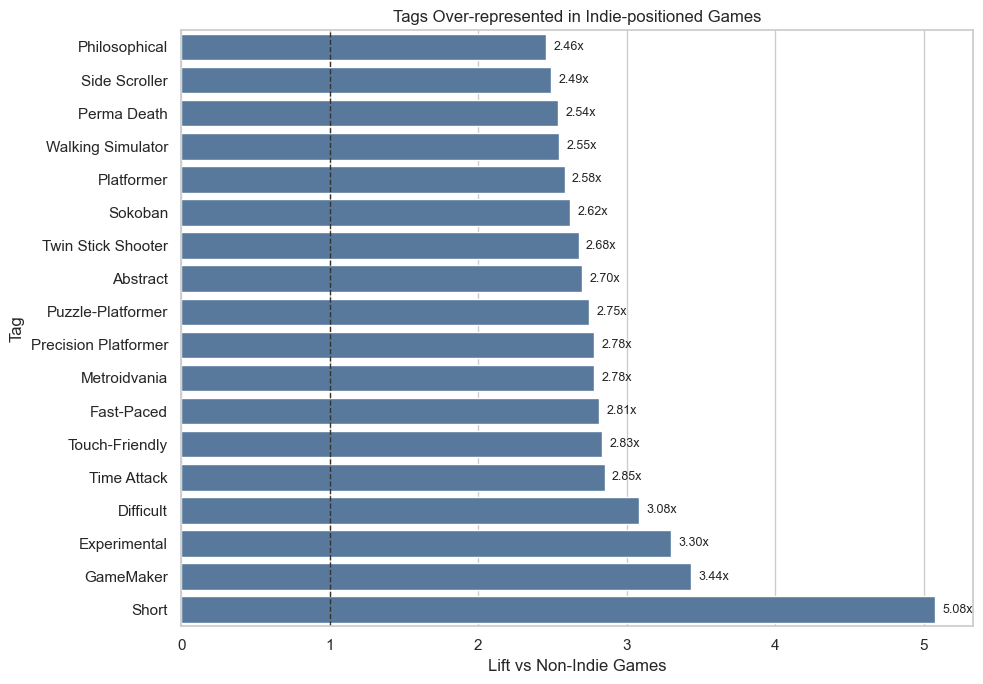

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/36_indie_tag_lift.png


In [16]:
plot_indie_lift = indie_lift.head(18).sort_values("lift", ascending=True)
plt.figure(figsize=(10, 7))
ax = sns.barplot(data=plot_indie_lift, y="tag", x="lift", color="#4C78A8")
plt.axvline(1, color="#333333", linestyle="--", linewidth=1)
plt.title("Tags Over-represented in Indie-positioned Games")
plt.xlabel("Lift vs Non-Indie Games")
plt.ylabel("Tag")
for i, row in plot_indie_lift.reset_index(drop=True).iterrows():
    ax.text(row["lift"] + 0.05, i, f"{row['lift']:.2f}x", va="center", fontsize=9)
save_figure("36_indie_tag_lift.png")

独立游戏并不是单一内容类型，而是一组市场定位的组合。通过 lift 可以看到哪些标签更常出现在独立游戏语境中，这有助于把“独立游戏”从泛泛的类别，拆成更具体的题材和玩法方向。

## 9. 标签数量与市场定位复杂度

标签数量可以粗略反映一个游戏的定位复杂度：标签越多，说明游戏可能被赋予更多玩法、题材或体验描述。

本节观察标签数量和玩家反馈/热度之间是否存在直观关系。这里仍然只看相关性，不做因果解释。

,tags_item_count,game_count,median_review_count,median_positive_rate_30plus,mean_attention_score
0,0,16872,0.000,64.425,-0.615
1,1,497,9.000,60.000,-0.295
2,2,1704,12.000,62.162,-0.276
3,3,3216,15.000,68.000,-0.221
4,4,3099,23.000,70.000,-0.141
5,5,3634,20.000,74.513,-0.135
6,6,2927,26.000,75.379,-0.063
7,7,2604,23.000,77.400,-0.047
8,8,2374,26.000,77.066,0.007
9,9,2104,22.000,77.646,0.006


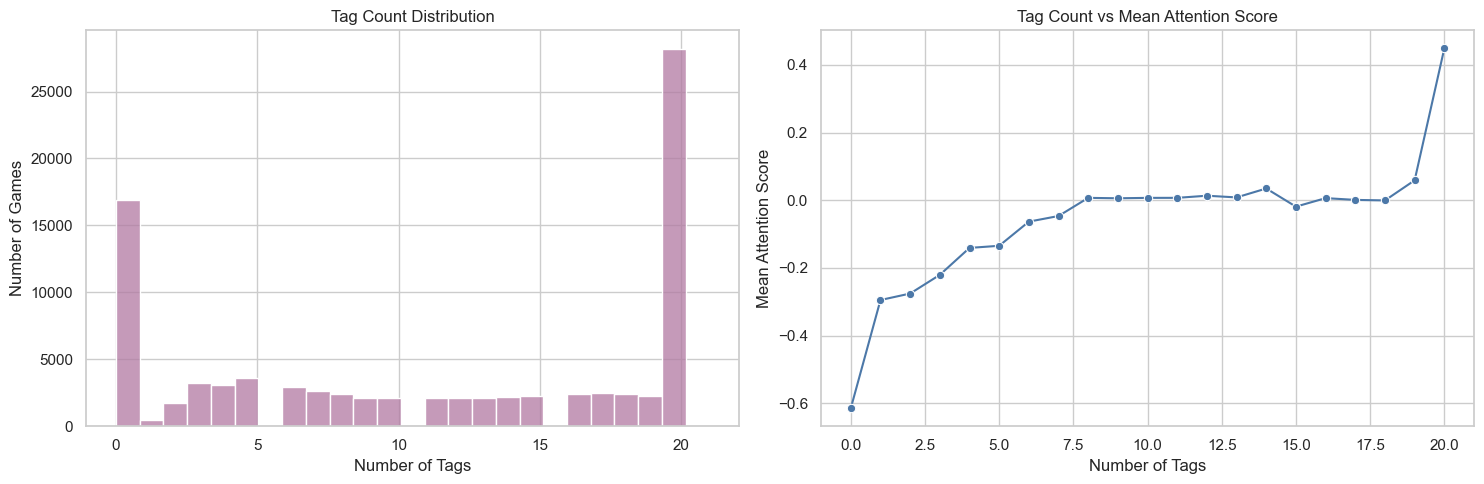

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/37_tag_count_positioning_complexity.png


In [17]:
tag_count_summary = analysis_df.groupby("tags_item_count").agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    median_positive_rate_30plus=("positive_rate_calc", lambda s: s[analysis_df.loc[s.index, "has_reliable_positive_rate"]].median()),
    mean_attention_score=("attention_score_descriptive", "mean")
).reset_index()

display(tag_count_summary.head(25))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=analysis_df, x="tags_item_count", bins=25, ax=axes[0], color="#B279A2")
axes[0].set_title("Tag Count Distribution")
axes[0].set_xlabel("Number of Tags")
axes[0].set_ylabel("Number of Games")

plot_tag_count = tag_count_summary[tag_count_summary["game_count"] >= 100]
sns.lineplot(data=plot_tag_count, x="tags_item_count", y="mean_attention_score", marker="o", ax=axes[1], color="#4C78A8")
axes[1].set_title("Tag Count vs Mean Attention Score")
axes[1].set_xlabel("Number of Tags")
axes[1].set_ylabel("Mean Attention Score")
save_figure("37_tag_count_positioning_complexity.png")

标签数量多并不一定代表游戏更好，但它可能说明游戏有更丰富的商店定位信息。对未来相似游戏推荐来说，标签数量和标签组合都可能影响相似度计算。

## 10. 为未来推荐系统准备的标签/类型特征说明

项目最后可能会做一个简单的 Steam 相似游戏推荐系统。这个推荐系统不放在当前 Notebook 实现，但本节可以把前面的分析转化为特征设计建议。

这里导出一个轻量级的游戏定位特征表，只包含 `appid`、`name`、类型、分类、标签、文本长度和热度指标。它不是大型 Parquet，而是一个较小的 CSV 样例，用于说明未来推荐系统可以使用哪些字段。

In [18]:
positioning_features = analysis_df[[
    "appid", "name", "genres_items", "categories_items", "tags_items",
    "genres_item_count", "categories_item_count", "tags_item_count",
    "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu",
    "attention_score_descriptive", "is_indie_positioned"
]].copy()

# 为了适合 GitHub 和课程检查，只保存前 5000 行样例。完整版本可由 Notebook 重新生成。
positioning_sample_path = PROCESSED_DIR / "steam_positioning_features_sample.csv"
positioning_features.head(5000).to_csv(positioning_sample_path, index=False)
print("Saved sample positioning features:", positioning_sample_path)
display(positioning_features.head())

Saved sample positioning features: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_positioning_features_sample.csv


,appid,name,genres_items,categories_items,tags_items,genres_item_count,categories_item_count,tags_item_count,review_count_calc,positive_rate_calc,recommendations,peak_ccu,attention_score_descriptive,is_indie_positioned
0,730,Counter-Strike 2,"[Action, Free To Play]","[Multi-player, Cross-Platform Multiplayer, Ste...","[FPS, Shooter, Multiplayer, Competitive, Actio...",2,11,20,8615921,86.825,4401572,1212356,7.346,False
1,578080,PUBG: BATTLEGROUNDS,"[Action, Adventure, Massively Multiplayer, Fre...","[Multi-player, PvP, Online PvP, Stats, Remote ...","[Survival, Shooter, Battle Royale, Multiplayer...",4,6,20,2512396,59.225,1732007,616738,6.870,False
2,570,Dota 2,"[Action, Strategy, Free To Play]","[Multi-player, Co-op, Steam Trading Cards, Ste...","[Free to Play, MOBA, Multiplayer, Strategy, e-...",3,8,20,2449800,81.577,14337,555977,6.223,False
3,271590,Grand Theft Auto V Legacy,"[Action, Adventure]","[Single-player, Multi-player, PvP, Online PvP,...","[Open World, Action, Multiplayer, Crime, Autom...",2,11,20,1969962,87.309,1803063,117698,6.384,False
4,359550,Tom Clancy's Rainbow Six® Siege,[Action],"[Single-player, Multi-player, PvP, Online PvP,...","[FPS, PvP, e-sports, Multiplayer, Tactical, Sh...",1,11,20,1371209,84.069,1165929,89916,6.204,False


这个样例表说明了后续推荐系统可以怎样使用当前 Notebook 的成果：标签、类型和分类可以作为相似度核心，评论数、好评率和热度指标可以作为过滤或排序辅助，而不是简单地只推荐最热门游戏。

## 11. 初步洞察总结

最后，本节根据前面的统计表和图表，自动生成一段适合课程报告使用的中文总结。总结只使用已经计算出的结果，不编造未运行的结论。

In [19]:
unique_tags = tag_long["tag"].nunique()
unique_genres = genre_long["genre"].nunique()
unique_categories = category_long["category"].nunique()
avg_tags = analysis_df["tags_item_count"].mean()
top_tag = top_tags.iloc[0]["tag"]
top_genre = top_genres.iloc[0]["genre"]
top_category = top_categories.iloc[0]["category"]

best_niche_tag = niche_high_feedback.iloc[0]["tag"] if len(niche_high_feedback) else "N/A"
best_attention_tag = high_attention_tags.iloc[0]["tag"] if len(high_attention_tags) else "N/A"
best_indie_lift_tag = indie_lift.iloc[0]["tag"] if len(indie_lift) else "N/A"
best_cooc_pair = cooc_pair_df.iloc[0] if len(cooc_pair_df) else None
cooc_text = f"共现相似度最高的 Top 标签组合之一是 **{best_cooc_pair['tag_a']} + {best_cooc_pair['tag_b']}**。" if best_cooc_pair is not None else "本次没有生成有效的标签共现组合。"

summary_md = f"""
### 可写入报告的初步结论

1. 当前 Steam 数据中共解析出 **{unique_genres}** 个类型、**{unique_categories}** 个分类和 **{unique_tags}** 个标签。平均每款游戏拥有约 **{avg_tags:.2f}** 个标签，说明 `tags` 是比 `genres` 更细粒度的市场定位语言。

2. 从覆盖规模看，出现频率最高的类型、分类和标签分别是 **{top_genre}**、**{top_category}** 和 **{top_tag}**。这些高频定位词代表 Steam 市场中的主流供给方向，但也意味着相应方向竞争更强。

3. 标签竞争度与反馈表现并不完全一致。某些标签覆盖游戏数量很多，但好评率或热度未必最高；也存在一些覆盖规模较小但反馈较好的标签候选，例如 **{best_niche_tag}**。这说明从复杂数据中可以挖掘更细分的市场定位线索。

4. 按描述性综合热度分数排序，代表性高热度标签之一是 **{best_attention_tag}**。这类标签更接近玩家关注度较高的内容方向，但不应被直接解释为因果关系。

5. 类型-标签矩阵显示，粗粒度类型和细粒度标签之间存在明显组合关系。同一类型下，不同标签组合可以代表不同玩法、题材和玩家预期。

6. {cooc_text} 标签共现说明 Steam 标签不是孤立存在，而是经常以组合方式描述游戏定位。

7. 独立游戏子市场中，相对更突出的标签之一是 **{best_indie_lift_tag}**。这说明 `Indie` 本身还可以进一步拆解为更具体的内容和体验方向。

8. 本 Notebook 为未来相似游戏推荐系统提供了基础：推荐可以基于标签、类型、分类和文本字段计算相似度，再用评论数、好评率和热度指标作为辅助排序或过滤信号。但推荐系统不在本 Notebook 中实现。
"""

display(Markdown(summary_md))


### 可写入报告的初步结论

1. 当前 Steam 数据中共解析出 **33** 个类型、**40** 个分类和 **452** 个标签。平均每款游戏拥有约 **11.26** 个标签，说明 `tags` 是比 `genres` 更细粒度的市场定位语言。

2. 从覆盖规模看，出现频率最高的类型、分类和标签分别是 **Indie**、**Single-player** 和 **Indie**。这些高频定位词代表 Steam 市场中的主流供给方向，但也意味着相应方向竞争更强。

3. 标签竞争度与反馈表现并不完全一致。某些标签覆盖游戏数量很多，但好评率或热度未必最高；也存在一些覆盖规模较小但反馈较好的标签候选，例如 **Sokoban**。这说明从复杂数据中可以挖掘更细分的市场定位线索。

4. 按描述性综合热度分数排序，代表性高热度标签之一是 **Games Workshop**。这类标签更接近玩家关注度较高的内容方向，但不应被直接解释为因果关系。

5. 类型-标签矩阵显示，粗粒度类型和细粒度标签之间存在明显组合关系。同一类型下，不同标签组合可以代表不同玩法、题材和玩家预期。

6. 共现相似度最高的 Top 标签组合之一是 **Indie + Singleplayer**。 标签共现说明 Steam 标签不是孤立存在，而是经常以组合方式描述游戏定位。

7. 独立游戏子市场中，相对更突出的标签之一是 **Short**。这说明 `Indie` 本身还可以进一步拆解为更具体的内容和体验方向。

8. 本 Notebook 为未来相似游戏推荐系统提供了基础：推荐可以基于标签、类型、分类和文本字段计算相似度，再用评论数、好评率和热度指标作为辅助排序或过滤信号。但推荐系统不在本 Notebook 中实现。
